# Bài tập buổi 6 — Hồi quy tuyến tính

**Sinh viên thực hiện:** "Nguyễn Văn A" (Thay tên của bạn)

---

## Bối cảnh

Trong bài tập này, bạn sẽ làm việc với bộ dữ liệu **California Housing** (Dự đoán giá nhà tại California dựa trên các đặc trưng nhân khẩu học và địa lý). Bài toán đặt ra là bài toán **Hồi quy (Regression)**.

Nhiệm vụ của bạn là xây dựng luồng xử lý dữ liệu và huấn luyện 3 biến thể của Hồi quy tuyến tính:
1. **Vanilla Linear Regression** (Hồi quy tuyến tính thông thường)
2. **Ridge Regression** (Hồi quy với chuẩn hóa L2)
3. **Lasso Regression** (Hồi quy với chuẩn hóa L1)

## Mục tiêu bài tập

1. Thực hiện Load dữ liệu và Khám phá dữ liệu (EDA) cơ bản.
2. Chia tập Train/Test và tiền xử lý (Scaling) đúng chuẩn, không gây Data Leakage.
3. Huấn luyện và đánh giá mô hình bằng các metric chuẩn cho Regression (RMSE, R²).
4. **Trực quan hóa hệ số hồi quy (Coefficients)** để hiểu rõ tính chất thu nhỏ (shrinkage) của Ridge và khả năng chọn lọc đặc trưng (feature selection) của Lasso.

---


## 0. Chuẩn bị môi trường & Import Thư viện

Ô này chứa sẵn các thư viện cần thiết. Nếu bạn cần dùng thêm thư viện nào, hãy bổ sung vào đây.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
np.random.seed(42)  # Cố định random seed
print("Đã import xong thư viện.")

Đã import xong thư viện.


---
## Task 1 — Tải dữ liệu và Khám phá ban đầu (EDA)


In [16]:
# TODO 1: Load dữ liệu, tạo DataFrame và kiểm tra tổng quan

# california = fetch_california_housing(as_frame=True)
# df = california.frame
california = fetch_california_housing(as_frame=True)
df = california.frame
# In shape, info và kiểm tra missing values
print("Shape:", df.shape)
print("Info:")
df.info()
print("Missing values:")
print(df.isnull().sum())


Shape: (20640, 9)
Info:
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
Missing values:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


---
## Task 2 — Trực quan hóa Phân phối & Tương quan


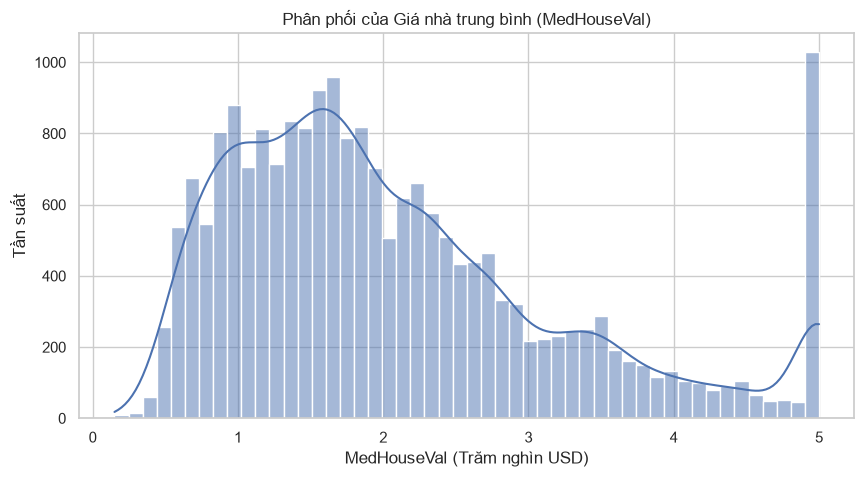

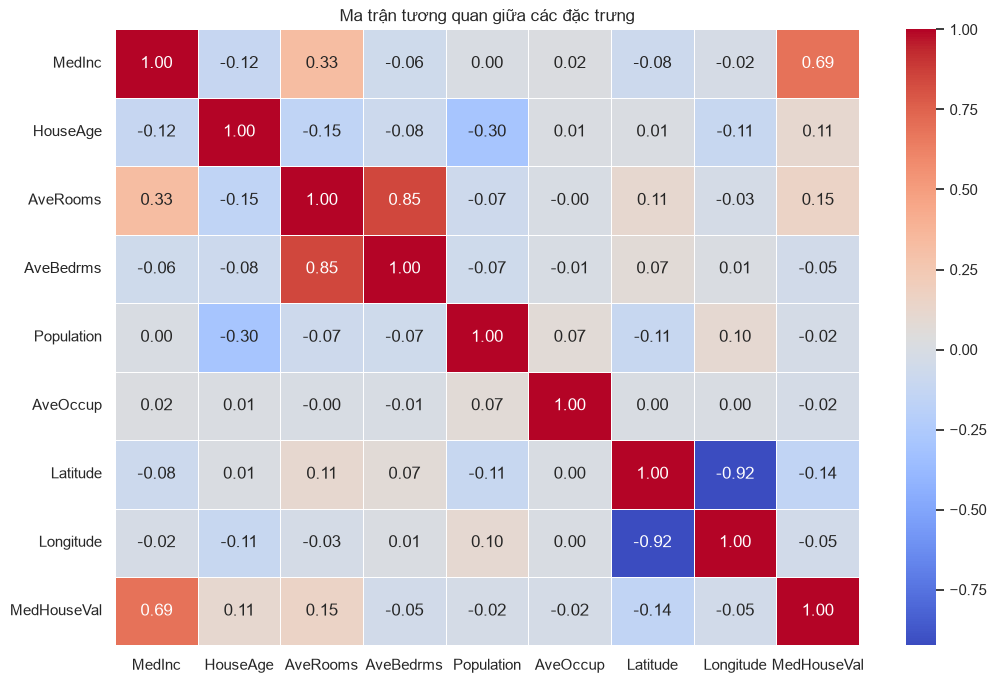

In [11]:
# TODO 2a: Vẽ Histogram cho biến MedHouseVal
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='MedHouseVal', kde=True, bins=50)
plt.title('Phân phối của Giá nhà trung bình (MedHouseVal)')
plt.xlabel('MedHouseVal (Trăm nghìn USD)')
plt.ylabel('Tần suất')
plt.show()

# TODO 2b: Vẽ Heatmap correlation cho toàn bộ dữ liệu
plt.figure(figsize=(12, 8))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Ma trận tương quan giữa các đặc trưng')
plt.show()


**Trả lời 2:**

- **Phân phối của MedHouseVal:** Phân phối hơi lệch phải (right-skewed). Đáng chú ý là có một sự bất thường (đỉnh cao - spike) ở giá trị khoảng 5.0 (500,000 USD). Điều này cho thấy dữ liệu có thể đã bị "cắt ngọn" (capped) ở ngưỡng 5.0 đối với các căn nhà có giá lớn hơn.
- **Đặc trưng tương quan mạnh nhất:** Dựa trên Heatmap, đặc trưng có độ tương quan dương mạnh nhất với giá nhà (`MedHouseVal`) là **`MedInc` (Thu nhập trung bình)** với hệ số tương quan là 0.69.

---
## Task 3 — Chia tập dữ liệu và Tiền xử lý (Scaling)


In [4]:
# TODO 3: Chia tập và Scale dữ liệu
X = df.drop(columns=['MedHouseVal'])
y = df['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
# Fit và transform trên tập train
X_train_scaled = scaler.fit_transform(X_train)
# Chỉ transform trên tập test (tránh Data Leakage)
X_test_scaled = scaler.transform(X_test)


---
## Task 4 — Huấn luyện Vanilla Linear Regression


In [5]:
# TODO 4: Huấn luyện và Đánh giá Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)
print(f"Linear Regression - RMSE: {rmse_lr:.4f}, R2: {r2_lr:.4f}")


Linear Regression - RMSE: 0.7456, R2: 0.5758


---
## Task 5 — Huấn luyện Ridge và Lasso Regression


In [6]:
# Hàm hỗ trợ đánh giá
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    print(f"{model_name} - RMSE: {rmse:.4f}, R2: {r2:.4f}")
    return rmse, r2

# TODO 5a: Huấn luyện và Đánh giá Ridge Regression
ridge_model = Ridge(alpha=10.0)
ridge_model.fit(X_train_scaled, y_train)
evaluate_model(ridge_model, X_test_scaled, y_test, "Ridge Regression")

# TODO 5b: Huấn luyện và Đánh giá Lasso Regression
lasso_model = Lasso(alpha=0.1)
lasso_model.fit(X_train_scaled, y_train)
evaluate_model(lasso_model, X_test_scaled, y_test, "Lasso Regression")


Ridge Regression - RMSE: 0.7453, R2: 0.5761
Lasso Regression - RMSE: 0.8244, R2: 0.4814


(np.float64(0.8243961598848472), 0.48136113250290735)

---
## Task 6 — Trực quan hóa Hệ số hồi quy (Coefficients)


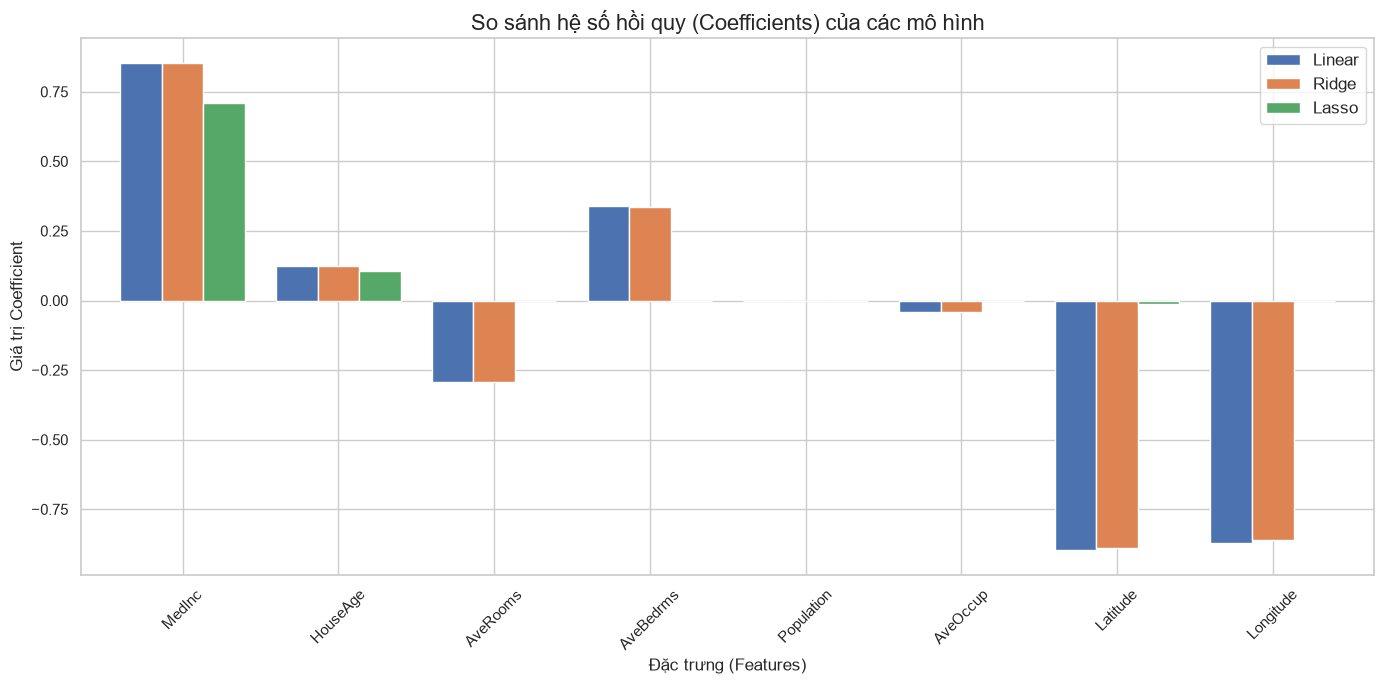

In [7]:
# TODO 6: Trực quan hóa Coefficients
features = X.columns
coef_df = pd.DataFrame({
    'Linear': lr_model.coef_,
    'Ridge': ridge_model.coef_,
    'Lasso': lasso_model.coef_
}, index=features)

# Vẽ biểu đồ so sánh
coef_df.plot(kind='bar', figsize=(14, 7), width=0.8)
plt.title("So sánh hệ số hồi quy (Coefficients) của các mô hình", fontsize=16)
plt.ylabel("Giá trị Coefficient", fontsize=12)
plt.xlabel("Đặc trưng (Features)", fontsize=12)
plt.xticks(rotation=45)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()


**Trả lời 6:**

Khi quan sát hệ số của **Lasso Regression**, ta thấy nhiều đặc trưng (ví dụ: `HouseAge`, `AveRooms`, `AveBedrms`, `Population`, `AveOccup`, `Latitude`, `Longitude`) bị ép về đúng giá trị **0**. Trong khi đó, Linear và Ridge vẫn giữ lại hệ số khác 0 cho các biến này.

**Ý nghĩa & Ứng dụng:** 
Tính chất này của Lasso được ứng dụng làm **Feature Selection (Chọn lọc đặc trưng)**. Lasso tự động loại bỏ các biến ít quan trọng bằng cách gán trọng số bằng 0, từ đó giúp:
- Đơn giản hóa mô hình (Sparse model), dễ diễn giải hơn.
- Tránh hiện tượng Overfitting khi làm việc với bộ dữ liệu có quá nhiều chiều (nhiều đặc trưng nhiễu).
- Cải thiện tốc độ tính toán khi dự đoán.

---
## (Bonus) Task 7 — Tìm siêu tham số tối ưu với GridSearchCV


In [8]:
from sklearn.model_selection import GridSearchCV

# TODO Bonus: GridSearchCV cho Ridge
param_grid = {'alpha': [0.1, 1.0, 10.0, 100.0]}
grid_search = GridSearchCV(Ridge(), param_grid, cv=5, scoring='neg_root_mean_squared_error')
grid_search.fit(X_train_scaled, y_train)

print(f"Alpha tốt nhất cho Ridge: {grid_search.best_params_}")
print(f"RMSE chéo tốt nhất (CV): {-grid_search.best_score_:.4f}")


Alpha tốt nhất cho Ridge: {'alpha': 0.1}
RMSE chéo tốt nhất (CV): 0.7205


---
## Bảng tự kiểm trước khi nộp

- [x] Notebook chạy **Restart & Run All** không bị lỗi NameError hay SyntaxError.
- [x] Đã hoàn thiện bước Scale dữ liệu cẩn thận, không có Data Leakage.
- [x] Đã trực quan hóa đủ các biểu đồ ở Task 2 và Task 6.
- [x] Đã trả lời phần nhận xét bằng Text ở các câu hỏi (Task 2, Task 6).
